In [ ]:
#@title Default title text
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#!ls 'drive/My Drive/local training'
import os
os.chdir('drive/My Drive/Doktora/TBC')

Mounted at /content/drive


In [ ]:
!pip install laspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 2.6 MB/s eta 0:00:00


In [ ]:
import laspy
import numpy as np
from sklearn.cluster import Birch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# LAS dosyasını yükleme
las = laspy.read("deneme_tlg.las")

# Nokta bulutu koordinatlarını bir numpy dizisine dönüştürme
points = np.vstack((las.x, las.y, las.z)).T  # X, Y, Z koordinatları

Text(0.5, 0.92, 'LAS Verisi - 3D Görselleştirme')

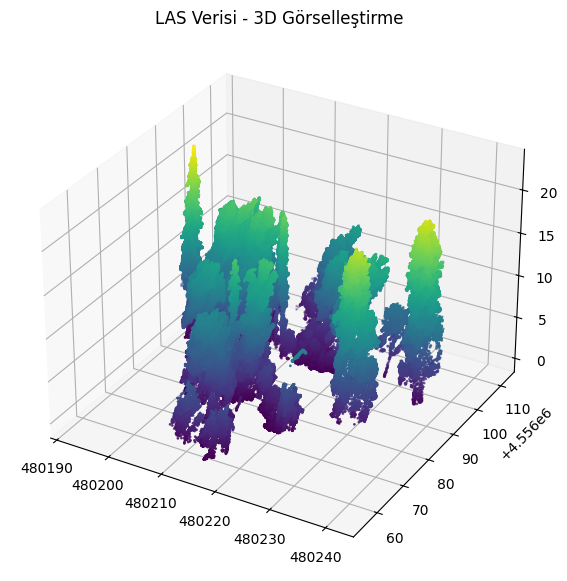

In [ ]:
# Matplotlib ile 3D görselleştirme
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Noktaları çiz
ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=points[:, 2], cmap='viridis', s=1)

# Eksen etiketleri
ax.set_title("LAS Verisi - 3D Görselleştirme")

In [ ]:
# Birch algoritmasını tanımlayın
birch = Birch(threshold=5, branching_factor=50, n_clusters=None)

# Modeli eğitip veriye uygulayın
birch.fit(points)
labels = birch.labels_

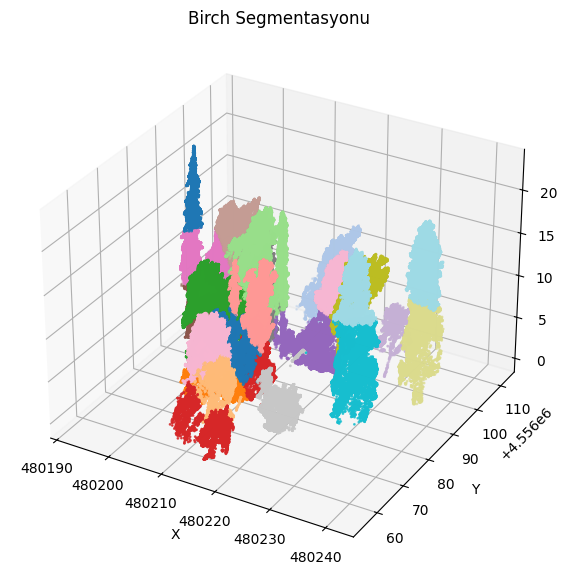

In [ ]:
# Her segment için rastgele bir renk atama
unique_labels = np.unique(labels)
colors = plt.cm.tab20(labels / unique_labels.max())

# Nokta bulutunu görselleştirme
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=1)
ax.set_title("Birch Segmentasyonu")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

In [ ]:
print(f"Küme Sayısı: {len(np.unique(labels))}")

NameError: name 'labels' is not defined

In [ ]:
for t in [2, 5, 10, 20]:
    birch = Birch(threshold=t, branching_factor=50, n_clusters=None)
    birch.fit(points)
    print(f"Threshold: {t}, Küme Sayısı: {len(np.unique(birch.labels_))}")

Threshold: 2, Küme Sayısı: 276
Threshold: 5, Küme Sayısı: 24
Threshold: 10, Küme Sayısı: 8
Threshold: 20, Küme Sayısı: 1


In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
# DBSCAN modelini tanımlama
dbscan = DBSCAN(eps=0.5, min_samples=10)  # eps: Komşuluk yarıçapı, min_samples: Minimum nokta sayısı

# Modeli eğitme ve etiketleme
labels = dbscan.fit_predict(points)

# Küme sayısını hesaplama (gürültü kümeleri hariç)
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Küme Sayısı: {num_clusters}")

Küme Sayısı: 70


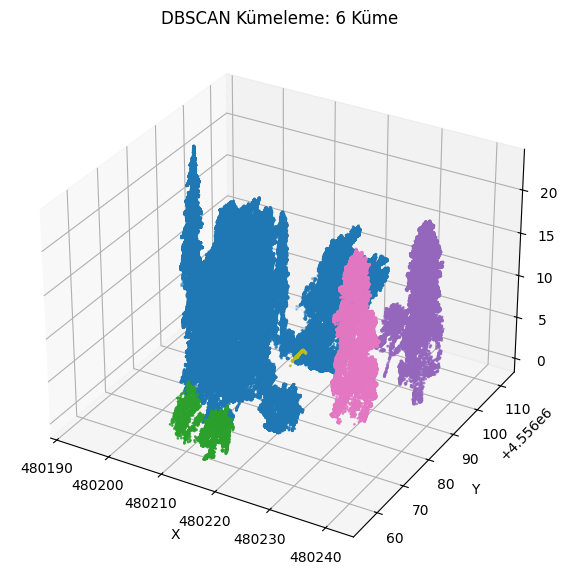

In [ ]:
# Her küme için rastgele bir renk atama
unique_labels = np.unique(labels)
colors = plt.cm.tab20(labels / max(unique_labels) if unique_labels.max() > 0 else 1)
colors[labels < 0] = 0  # Gürültü noktalarını siyah yap

# Nokta bulutunu görselleştirme
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=1)
ax.set_title(f"DBSCAN Kümeleme: {num_clusters} Küme")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [ ]:
for eps in [1, 2, 5]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(points)
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps: {eps}, Küme Sayısı: {num_clusters}")

eps: 1, Küme Sayısı: 10
eps: 2, Küme Sayısı: 6


In [ ]:
from sklearn.cluster import KMeans

In [ ]:
model = KMeans(n_clusters=20)

model.fit(points)

KMeans(n_clusters=20)

In [ ]:
el = np.unique(model.labels_)

print(len(el))

20


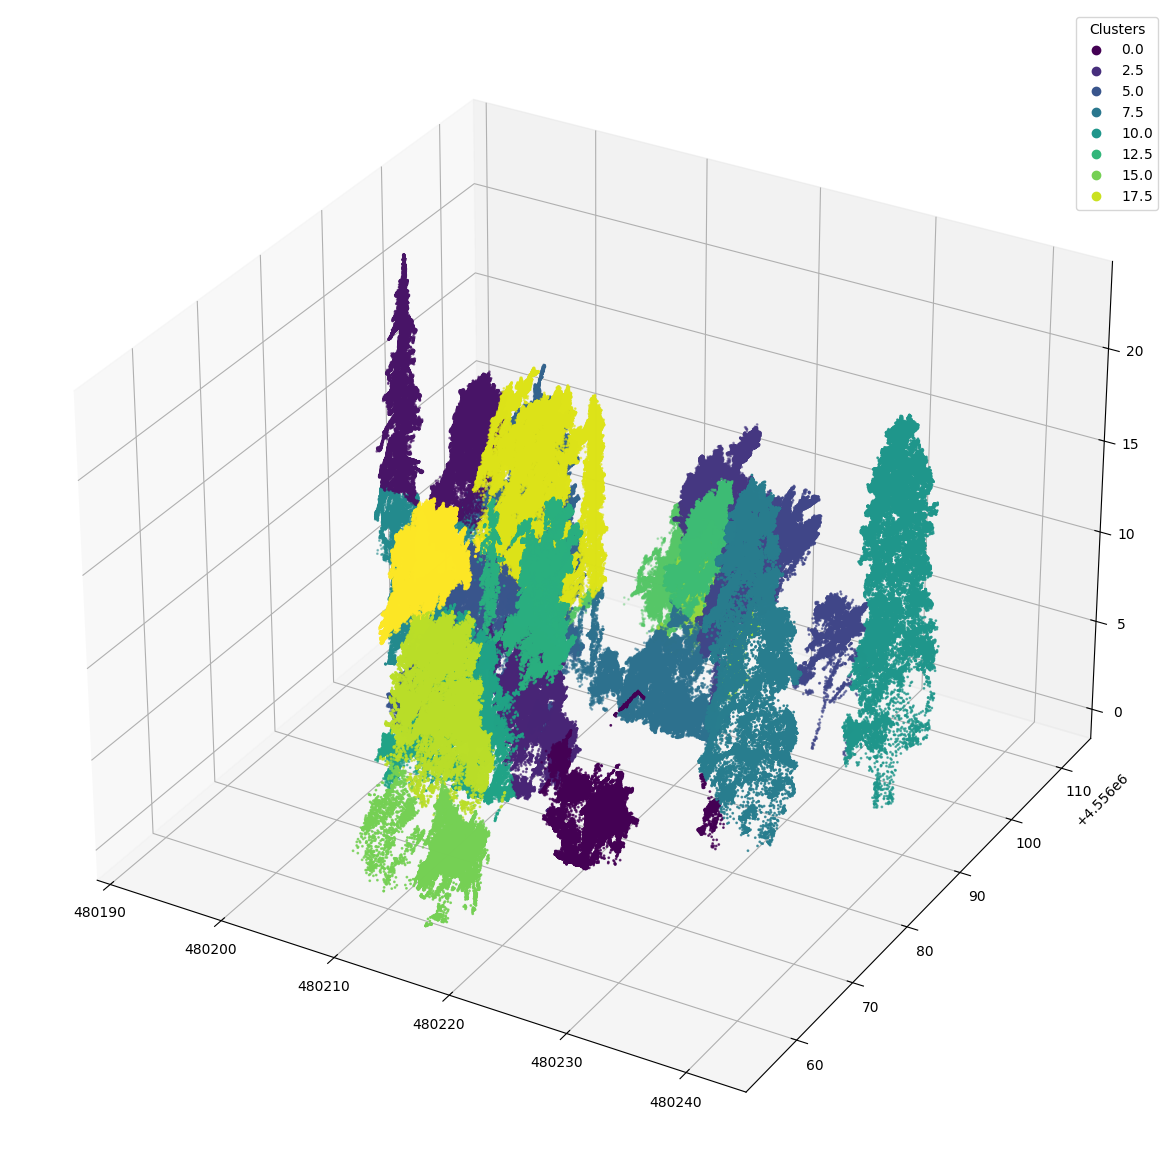

In [ ]:
fig = plt.figure(figsize=(15,15))
ax= fig.add_subplot(111, projection='3d')

scatter = ax.scatter(points[:,0], points[:,1],points[:,2], s=1, c=model.labels_, )

legend = ax.legend(*scatter.legend_elements(),
                    loc="upper right", title="Clusters")

plt.show()

In [ ]:
from sklearn.cluster import MeanShift

In [ ]:
model = MeanShift(bandwidth=5)

model.fit_predict(points)

In [ ]:
el = np.unique(model.labels_)

print(len(el))

In [ ]:
fig = plt.figure(figsize=(15,15))
ax= fig.add_subplot(111, projection='3d')

scatter = ax.scatter(points[:,0], points[:,1],points[:,2], s=1, c=model.labels_, )

legend = ax.legend(*scatter.legend_elements(),
                    loc="upper right", title="Clusters")

plt.show()

In [ ]:
from sklearn.cluster import OPTICS

In [ ]:
model = OPTICS(min_samples=10, metric='euclidean')

model.fit_predict(points)

In [ ]:
el = np.unique(model.labels_)

print(len(el))

In [ ]:
fig = plt.figure(figsize=(15,15))
ax= fig.add_subplot(111, projection='3d')

scatter = ax.scatter(points[:,0], points[:,1],points[:,2], s=1, c=model.labels_, )

legend = ax.legend(*scatter.legend_elements(),
                    loc="upper right", title="Clusters")

plt.show()

In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
model = GaussianMixture(n_components=18)

model.fit(points)

GaussianMixture(n_components=18)

In [ ]:
el = np.unique(model.means_)

print(len(el))

labels = model.predict(points)

54


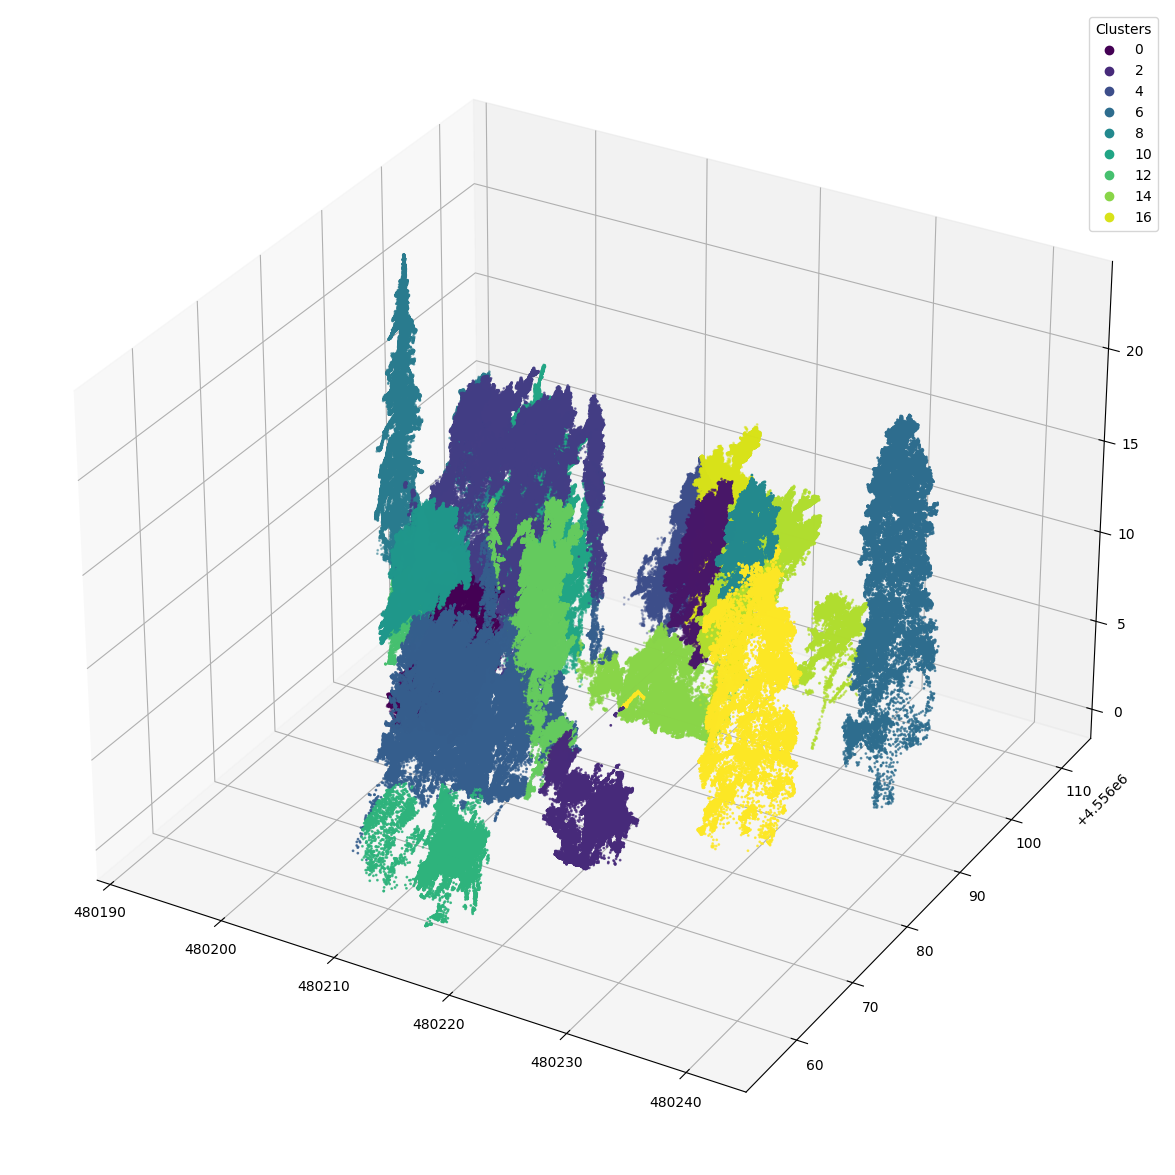

In [ ]:
fig = plt.figure(figsize=(15,15))
ax= fig.add_subplot(111, projection='3d')

scatter = ax.scatter(points[:,0], points[:,1],points[:,2], s=1, c=labels, )

legend = ax.legend(*scatter.legend_elements(),
                    loc="upper right", title="Clusters")

plt.show()